In [1]:
import numpy as np
import pandas as pd
from StochasticSimulationsNew.ReactionNetworkLanguage import make_parser
from StochasticSimulationsNew.MultiGPUsupport import SSA, spread_parameter_sets_among_gpus
from RL4CRN.utils.stochastic_visualizations import plot_simulation_summary
from RL4CRN.utils.stochastic import quick_measurement_SSA
from RL4CRN.utils.stochastic_visualizations import plot_simulation_summary

import math
import time  
import random

import logging 

logging.basicConfig(level=logging.INFO)

start_time = time.time()

parser, lexer = make_parser()

f = open('../../stochasticApproaches/Test/GE_std.rn')
text = ''.join(f.readlines())
crn = parser.parse(text)

# Gene Expression
# sample parameters within ranges
n_parameter_sets = 1
parameters = [
    [
        2,#random.random()+1,
        1,#random.random()+1,
        1,#random.random()+1,
        1 #random.random()+1
    ] for i in range(n_parameter_sets) ]

# BDP
# n_parameter_sets = 1000
# parameters = [
#     [
#         random.random()*10,
#         random.random()*10
#     ] for i in range(n_parameter_sets) ]


parameter_sets = spread_parameter_sets_among_gpus(parameters)
parmeter_order = ["kr", "kp", "gr", "gp"]

# ssa
output = SSA(crn, parameter_sets, parmeter_order, t_fin=10, n_trajectories=10000, t_step=0.1, t_control_step=-1)

# import os
# os.makedirs('scratch_output', exist_ok=True)
# output.to_csv('scratch_output/GE_100pfix_100t.csv', index=False)

# print(output)

end_time = time.time()

import warnings
warnings.filterwarnings("ignore", module="ipykernel.iostream")

logging.debug(f"ELAPSED TIME: {end_time-start_time}")

INFO:root:GPU 0 finished in 0.1282029151916504 seconds


In [2]:
output

,M,P,time,parameter_index,gpu,has_diverged,gp,gr,kp,kr
0,0,0,0.0,0,0,False,2,1,1,1
1,1,1,0.1,0,0,False,2,1,1,1
2,1,1,0.2,0,0,False,2,1,1,1
3,1,1,0.3,0,0,False,2,1,1,1
4,1,1,0.4,0,0,False,2,1,1,1
...,...,...,...,...,...,...,...,...,...,...
1009995,4,0,9.6,0,0,False,2,1,1,1
1009996,5,0,9.7,0,0,False,2,1,1,1
1009997,6,0,9.8,0,0,False,2,1,1,1
1009998,6,0,9.9,0,0,False,2,1,1,1


In [3]:
# Group by time and calculate mean and std for species P and M
summary = output.groupby('time')[['P', 'M']].agg(['mean', 'std'])

# Display the first few rows
print(summary)

           P                 M          
        mean       std    mean       std
time                                    
0.0   0.0000  0.000000  0.0000  0.000000
0.1   0.0075  0.088569  0.1870  0.432492
0.2   0.0335  0.198952  0.3519  0.589831
0.3   0.0712  0.285199  0.5051  0.711354
0.4   0.1184  0.379468  0.6506  0.807208
...      ...       ...     ...       ...
9.6   1.9586  1.710432  1.9952  1.419781
9.7   1.9651  1.723943  2.0006  1.425764
9.8   1.9703  1.732258  1.9991  1.430141
9.9   1.9766  1.743719  1.9990  1.417956
10.0  1.9771  1.743410  1.9989  1.410212

[101 rows x 4 columns]


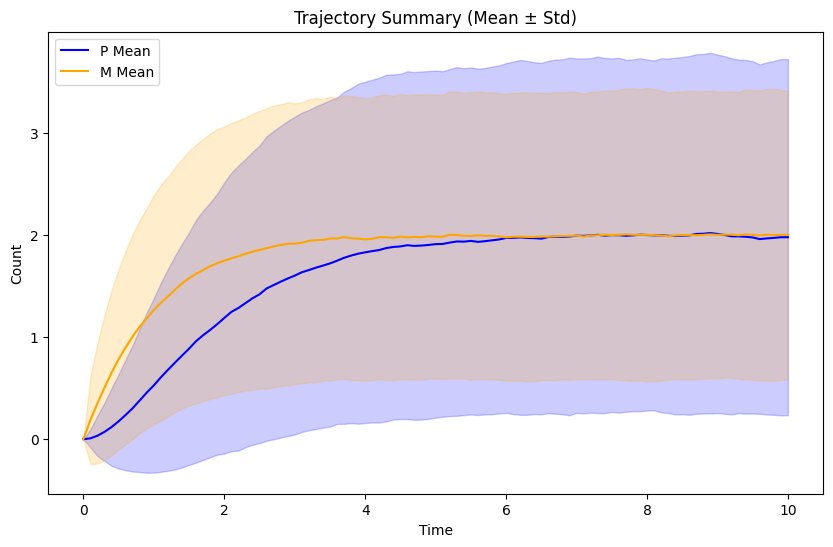

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Plot P
p_mean = summary[('P', 'mean')]
p_std = summary[('P', 'std')]
plt.plot(summary.index, p_mean, label='P Mean', color='blue')
plt.fill_between(summary.index, p_mean - p_std, p_mean + p_std, color='blue', alpha=0.2)

# Plot M
m_mean = summary[('M', 'mean')]
m_std = summary[('M', 'std')]
plt.plot(summary.index, m_mean, label='M Mean', color='orange')
plt.fill_between(summary.index, m_mean - m_std, m_mean + m_std, color='orange', alpha=0.2)

plt.xlabel('Time')
plt.ylabel('Count')
plt.title('Trajectory Summary (Mean ± Std)')
plt.legend()
plt.show()

In [5]:
crn_text = """
// --- Inputs (External Signals) ---
input u_1;
input u_2;
input u_3;

// --- Species Definition ---
species OUT, X_1, X_2, X_3 = 0;

// --- Reactions ---

// 1. Generation from inputs (0-order)
emptyset -- u_1 -> X_1:1;
emptyset -- u_2 -> X_2:1;
emptyset -- u_3 -> X_3:1;

// 2. Catalytic production of X_3 by X_1
// X_1 ----> X_1 + X_3
X_1:1 -- mak(0.05915942043066025) -> X_1:1, X_3:1;

// 3. Conversion of X_3 to OUT
// X_3 ----> OUT
X_3:1 -- mak(0.33624395728111267) -> OUT:1;

// 4. Conversion of OUT to X_2
// OUT ----> X_2
OUT:1 -- mak(1.1e1) -> X_2:1;

// 5. Annihilation of X_1 and X_2
// X_1 + X_2 ----> ∅
X_1:1, X_2:1 -- mak(2.170705556869507) -> emptyset;

// 6. Catalytic production of OUT by X_3 (requires 2 X_3 to proceed)
// X_3 + X_3 ----> OUT + X_3
X_3:2 -- mak(0.9167826771736145) -> OUT:1, X_3:1;
"""

parser, lexer = make_parser()
crn = parser.parse(crn_text)

import itertools 
# all combinations of 0,1 for three inputs
base = [0,1]
parameters = list(itertools.product(base, repeat=3))

parameter_sets = spread_parameter_sets_among_gpus(parameters)
parameter_names = ["u_1", "u_2", "u_3"]
output = SSA(crn, parameter_sets, parameter_names, t_fin=1000, n_trajectories=100, t_step=0.1, t_control_step=-1)


output


INFO:root:GPU 0 finished in 0.30105137825012207 seconds


,OUT,X_1,X_2,X_3,time,parameter_index,gpu,has_diverged,u_1,u_2,u_3
0,0,0,0,0,0.0,0,0,False,0,0,0
1,0,0,0,0,0.1,0,0,False,0,0,0
2,0,0,0,0,0.2,0,0,False,0,0,0
3,0,0,0,0,0.3,0,0,False,0,0,0
4,0,0,0,0,0.4,0,0,False,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
8000795,0,0,967,1,999.6,7,0,False,1,1,1
8000796,0,0,967,1,999.7,7,0,False,1,1,1
8000797,0,0,967,1,999.8,7,0,False,1,1,1
8000798,0,0,967,2,999.9,7,0,False,1,1,1


In [6]:
print(crn)


// species
species X_3 = 0;
species X_2 = 0;
species X_1 = 0;
species OUT = 0;

// parameters

// inputs
u_3 = ::in::;
u_2 = ::in::;
u_1 = ::in::;

// variables

// reactions
X_3:2 -- { function : ['{ number = 0.9167826771736145 }'] } -> OUT:1,X_3:1;
X_1:1,X_2:1 -- { function : ['{ number = 2.170705556869507 }'] } -> emptyset;
OUT:1 -- { function : ['{ number = 11.0 }'] } -> X_2:1;
X_3:1 -- { function : ['{ number = 0.33624395728111267 }'] } -> OUT:1;
X_1:1 -- { function : ['{ number = 0.05915942043066025 }'] } -> X_1:1,X_3:1;
emptyset -- { identifier = u_3 } -> X_3:1;
emptyset -- { identifier = u_2 } -> X_2:1;
emptyset -- { identifier = u_1 } -> X_1:1;



In [7]:
import pandas as pd
from RL4CRN.utils.stochastic import quick_measurement_SSA

# Example Usage
summary_output, has_diverged = quick_measurement_SSA(
    crn, 
    parameters, 
    parameter_names,
    t_fin=30, 
    n_trajectories=1000, 
    species_to_measure=['X_1']
)

summary_output

INFO:root:GPU 0 finished in 0.13643431663513184 seconds


time parameter_index has_diverged u_1 u_2 u_3     X_1          
                                                       mean       std
0      0.0               0        False   0   0   0   0.000  0.000000
1      0.0               1        False   0   0   1   0.000  0.000000
2      0.0               2        False   0   1   0   0.000  0.000000
3      0.0               3        False   0   1   1   0.000  0.000000
4      0.0               4        False   1   0   0   0.000  0.000000
...    ...             ...          ...  ..  ..  ..     ...       ...
2403  30.0               3        False   0   1   1   0.000  0.000000
2404  30.0               4        False   1   0   0  14.425  3.844627
2405  30.0               5        False   1   0   1   1.758  2.674432
2406  30.0               6        False   1   1   0   1.451  2.513945
2407  30.0               7        False   1   1   1   0.011  0.104355

[2408 rows x 8 columns]

In [8]:
# plot_simulation_summary(summary_output, species_cols=["X_1"])

In [9]:
%reload_ext autoreload
%autoreload 2

# Import general packages
from openpyxl import Workbook, load_workbook
from openpyxl.utils import get_column_letter
from datetime import datetime
import torch
from matplotlib import pyplot as plt
from pytorch_lightning.loggers import CometLogger
import numpy as np
from itertools import product
from tqdm import tqdm

# Import Agent-Environment packages
from RL4CRN.environments.environment import Environment
from RL4CRN.environments.parallel_environments import ParallelEnvironments
from RL4CRN.environments.serial_environments import SerialEnvironments
from RL4CRN.agents.reinforce_agent import REINFORCEAgent
from RL4CRN.policies.add_reaction_by_ordered_index import AddReactionByOrderedIndex
from RL4CRN.policies.add_reaction_by_index import AddReactionByIndex

# Import Interface packages
from RL4CRN.env2agent_interface.explicit_observer import ExplicitObserver
from RL4CRN.env2agent_interface.explicit_tensorizer import ExplicitTensorizer
from RL4CRN.agent2env_interface.library_actuator import LibraryActuator
from RL4CRN.agent2env_interface.iocrn_stepper import IOCRNStepper

# Import CRN packages
from RL4CRN.iocrns.iocrn import IOCRN
from RL4CRN.iocrns.reactions import MassAction
from RL4CRN.utils.ic import IC
from RL4CRN.iocrns.reaction_library import construct_mass_action_library

# Import Reward packages
from RL4CRN.rewards.deterministic import dynamic_tracking_error

In [10]:
# Construct the template CRN
# add dilution and production reactions for all species
productions = []
dilutions = []
n_inputs = 3
species_labels = [f'X_{i+1}' for i in range(n_inputs)] 
for i,s in enumerate(species_labels):
    productions.append(MassAction(reactant_labels=[], product_labels=[s], input_channels=[f'u_{i+1}'], params=[1.], params_controllability=[True]))
    dilutions.append(MassAction(reactant_labels=[s], product_labels=[], input_channels=["u_1"], params=[2.], params_controllability=[True])) 

# add x1 to out
productions.append(MassAction(reactant_labels=['X_1'], product_labels=['OUT'], input_channels=[None], params=[1.0], params_controllability=[True]))
# add diluting output
species_labels.append('OUT') # add output species label
# dilutions.append(MassAction(reactant_labels=['OUT'], product_labels=[], input_channels=[None], params=[1.0], params_controllability=[True]))
# productions.append(MassAction(reactant_labels=[], product_labels=['OUT'], input_channels=[None], params=[.5], params_controllability=[True]))

# support_nodes = ['S1', 'S2']
# species_labels.extend(support_nodes) # add support nodes to species labels

crn_template = IOCRN(productions + dilutions, output_labels=['OUT'])
crn_template.compile()
p = crn_template.num_inputs # Number of inputs of the IOCRNs
print("Template CRN:")
print(crn_template)

# Construct the library of possible reactions
library = construct_mass_action_library(species_labels=species_labels, order=2)
crn_template.set_library_context(library)
M = len(library.reactions) # Number of possible reactions
K = library.get_num_parameters() # Total number of parameters in all the reactions of the library
print("Library of possible reactions:")
print(library)
print("------------------------------------------------")

Template CRN:
Inputs: ['u_1', 'u_2', 'u_3'] 
Species: ['OUT', 'X_1', 'X_2', 'X_3'] 
Output Species: ['OUT'] 
∅ ----> X_1;  [MAK(1.0, u_1)]
∅ ----> X_2;  [MAK(1.0, u_2)]
∅ ----> X_3;  [MAK(1.0, u_3)]
X_1 ----> OUT;  [MAK(1.0)]
X_1 ----> ∅;  [MAK(2.0, u_1)]
X_2 ----> ∅;  [MAK(2.0, u_1)]
X_3 ----> ∅;  [MAK(2.0, u_1)]
Library of possible reactions:
Number of reactions: 211
R0: ∅ ----> ∅;  [MAK(None)]
R1: ∅ ----> X_1;  [MAK(None)]
R2: ∅ ----> X_2;  [MAK(None)]
R3: ∅ ----> X_3;  [MAK(None)]
R4: ∅ ----> OUT;  [MAK(None)]
R5: ∅ ----> X_1 + X_1;  [MAK(None)]
R6: ∅ ----> X_1 + X_2;  [MAK(None)]
R7: ∅ ----> X_1 + X_3;  [MAK(None)]
R8: ∅ ----> OUT + X_1;  [MAK(None)]
R9: ∅ ----> X_2 + X_2;  [MAK(None)]
R10: ∅ ----> X_2 + X_3;  [MAK(None)]
R11: ∅ ----> OUT + X_2;  [MAK(None)]
R12: ∅ ----> X_3 + X_3;  [MAK(None)]
R13: ∅ ----> OUT + X_3;  [MAK(None)]
R14: ∅ ----> OUT + OUT;  [MAK(None)]
R15: X_1 ----> ∅;  [MAK(None)]
R16: X_1 ----> X_2;  [MAK(None)]
R17: X_1 ----> X_3;  [MAK(None)]
R18: X_1 ----> OUT

In [11]:
# import time
# import itertools

# # --- 1. Define a Simple Timer Class ---
# class Benchmark:
#     def __init__(self, name):
#         self.name = name
    
#     def __enter__(self):
#         self.start_time = time.perf_counter()
#         return self
    
#     def __exit__(self, exc_type, exc_val, exc_tb):
#         self.end_time = time.perf_counter()
#         elapsed = self.end_time - self.start_time
#         print(f"⏱️  [{self.name:<20}] completed in {elapsed:.4f} seconds")

# # --- 2. Your Benchmarked Code ---

# # Segment A: DSL Generation (IOCRN -> String)
# with Benchmark("DSL Generation"):
#     crn_text = crn_template.to_reaction_file()

# # Segment B: Parsing (String -> Parser Object)
# with Benchmark("Parsing & Lexing"):
#     parser, lexer = make_parser()
#     crn = parser.parse(crn_text)

# # Segment C: Setup
# with Benchmark("Parameter Setup"):
#     # [0,1] 3 times -> 8 combinations
#     parameters = list(itertools.product([0,1], repeat=3))

# # Segment D: The Heavy Lifting (Simulation)
# with Benchmark("SSA Simulation"):
#     measurements, has_diverged = quick_measurement_SSA(
#         crn, 
#         parameters, 
#         t_fin=100, 
#         n_trajectories=1000, 
#         species_to_measure=['OUT']
#     )

# # Segment E: Plotting
# with Benchmark("Visualization"):
#     plot_simulation_summary(measurements, species_cols=["OUT"])

In [12]:
# import itertools 
# import numpy as np
# # Assuming specific library imports exist in your environment context:
# # from your_library import make_parser, spread_parameter_sets_among_gpus, SSA, plot_simulation_summary

# crn_text = """
# // --- Inputs (External Signals) ---
# input u_1;
# input u_2;

# // --- Species Definition ---
# species X_1, Z_1, Z_2 = 0;

# // --- Reactions ---
# emptyset -- u_1 -> Z_1:1;
# Z_1:1 -- mak(u_2) -> emptyset;
# """

# # Parse the new CRN
# parser, lexer = make_parser()
# crn_forthis = parser.parse(crn_text)

# # Create combinations of input levels
# # base = [0, 0.5, 1.0, 1.5, 2., 2.5
# base = [0, 1, 2]
# # We have 2 inputs: u_1, u_2
# parameters = list(itertools.product(base, [3, 4, 5]))

# # Distribute to GPU
# parameter_sets = spread_parameter_sets_among_gpus(parameters)

# # Run Simulation
# # Using the optimized settings you requested
# o = SSA(
#     crn_forthis, 
#     parameter_sets, 
#     t_fin=100, 
#     n_trajectories=10000, 
#     max_threads=10000, 
#     t_step=0.1, 
#     t_control_step=-1, 
#     max_value=100000
# )

# # Visualize Results for X_1
# plot_simulation_summary(o, species_cols=["Z_1"])

Warinig: multiple uses of species X_1 in same reaction. The number of involved molecules is summed by default
Warinig: multiple uses of species Z_2 in same reaction. The number of involved molecules is summed by default
Warinig: multiple uses of species X_1 in same reaction. The number of involved molecules is summed by default
Warinig: multiple uses of species Z_1 in same reaction. The number of involved molecules is summed by default
Warinig: multiple uses of species Z_1 in same reaction. The number of involved molecules is summed by default


INFO:root:GPU 0 finished in 0.1030726432800293 seconds


Plotting mode: Raw (Aggregating now)


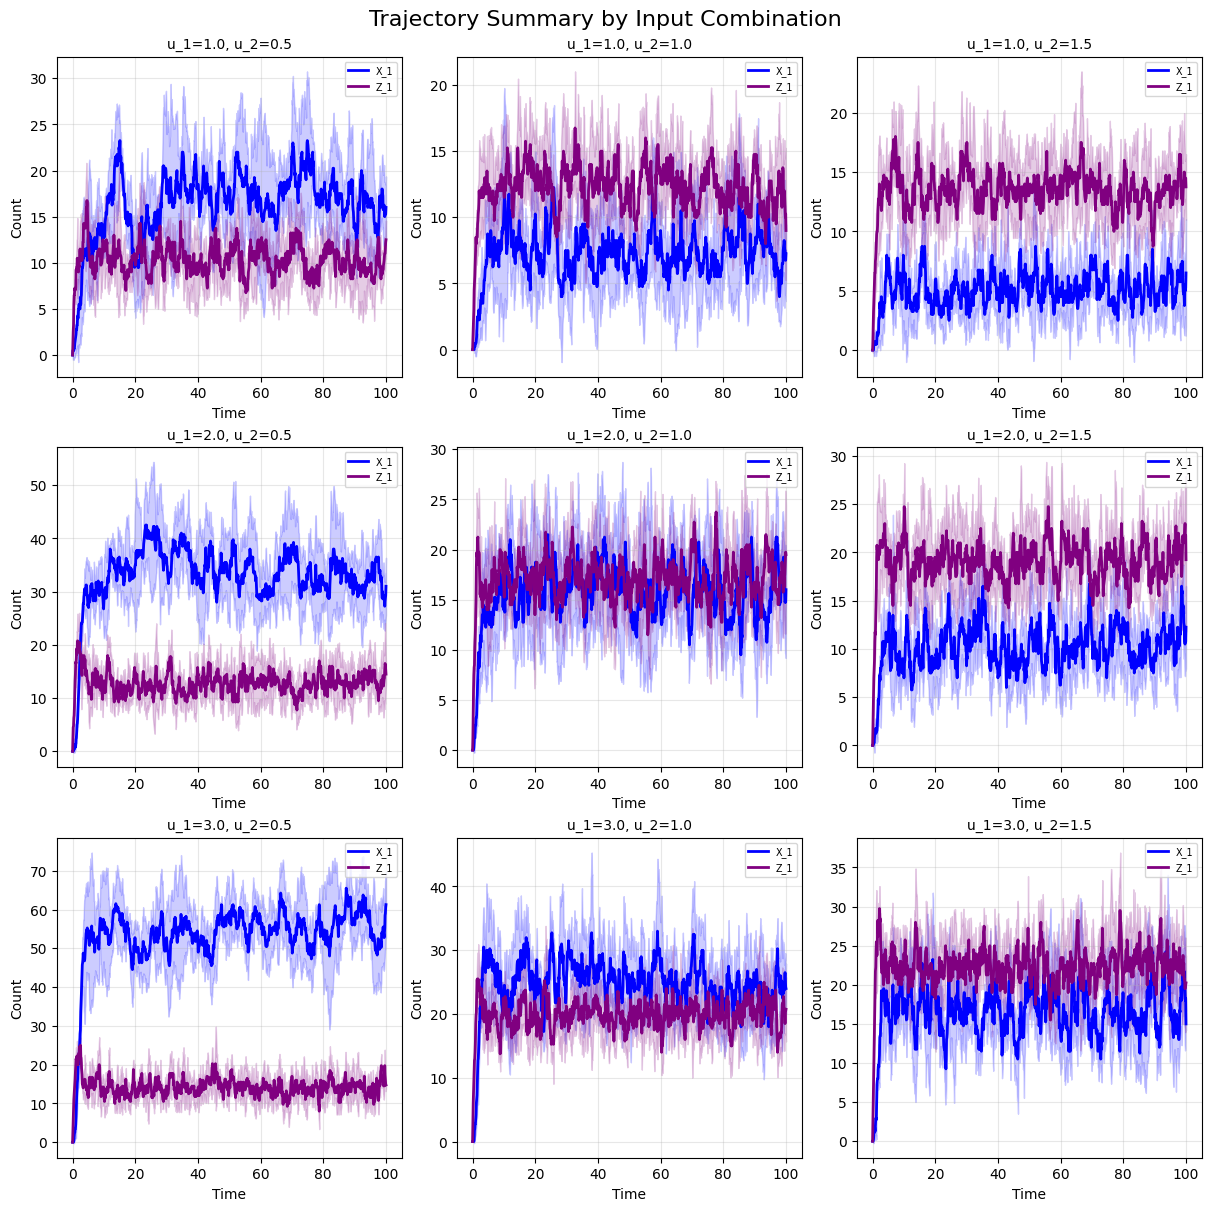

In [13]:
import itertools 
import numpy as np
# Assuming specific library imports exist in your environment context:
# from your_library import make_parser, spread_parameter_sets_among_gpus, SSA, plot_simulation_summary

crn_text = """
// --- Inputs (External Signals) ---
input u_1;
input u_2;

// --- Species Definition ---
species X_1, Z_1, Z_2 = 0;

// --- Reactions ---
// 1. Creation of Z_1 driven by u_1
emptyset -- 10.0 * u_1 -> Z_1;

// 2. Degradation of X_1 driven by u_2
X_1 -- mak(1.0 * u_2) -> emptyset;

// 3. Z_1 converts to 2 X_1
Z_1 -- mak(0.06266060471534729) -> X_1, X_1;

// 4. Z_1 converts to 2 Z_2
Z_1 -- mak(0.16304993629455566) -> Z_2, Z_2;

// 5. Catalytic replication of X_1 using Z_1
X_1, Z_1 -- mak(0.028185756877064705) -> X_1, X_1;

// 6. Annihilation/Fusion of Z_1 pairs
Z_1, Z_1 -- mak(0.014425482600927353) -> Z_1;

// 7. Interaction of Z_1 pairs to create X_1
Z_1, Z_1 -- mak(0.045602452009916306) -> X_1, Z_1;
"""

# Parse the new CRN
parser, lexer = make_parser()
crn_forthis = parser.parse(crn_text)

# Create combinations of input levels
# Adjusting base range to test different signal intensities
base = [1, 2, 3]
# We have 2 inputs: u_1, u_2
parameters = list(itertools.product(base, [0.5, 1, 1.5]))

# Distribute to GPU
parameter_sets = spread_parameter_sets_among_gpus(parameters)

# Run Simulation
# Using the optimized settings you requested
parameter_names = ["u_1", "u_2"]
o = SSA(
    crn_forthis, 
    parameter_sets, 
    parameter_names,
    t_fin=100, 
    n_trajectories=4, 
    t_step=0.1, 
    t_control_step=-1, 
    max_value=100000
)

# Visualize Results for all active species
plot_simulation_summary(o, species_cols=["X_1" , "Z_1"])

Warinig: multiple uses of species X_1 in same reaction. The number of involved molecules is summed by default
Warinig: multiple uses of species X_1 in same reaction. The number of involved molecules is summed by default
Warinig: multiple uses of species Z_2 in same reaction. The number of involved molecules is summed by default


INFO:root:GPU 0 finished in 2.7694337368011475 seconds


Plotting mode: Raw (Aggregating now)


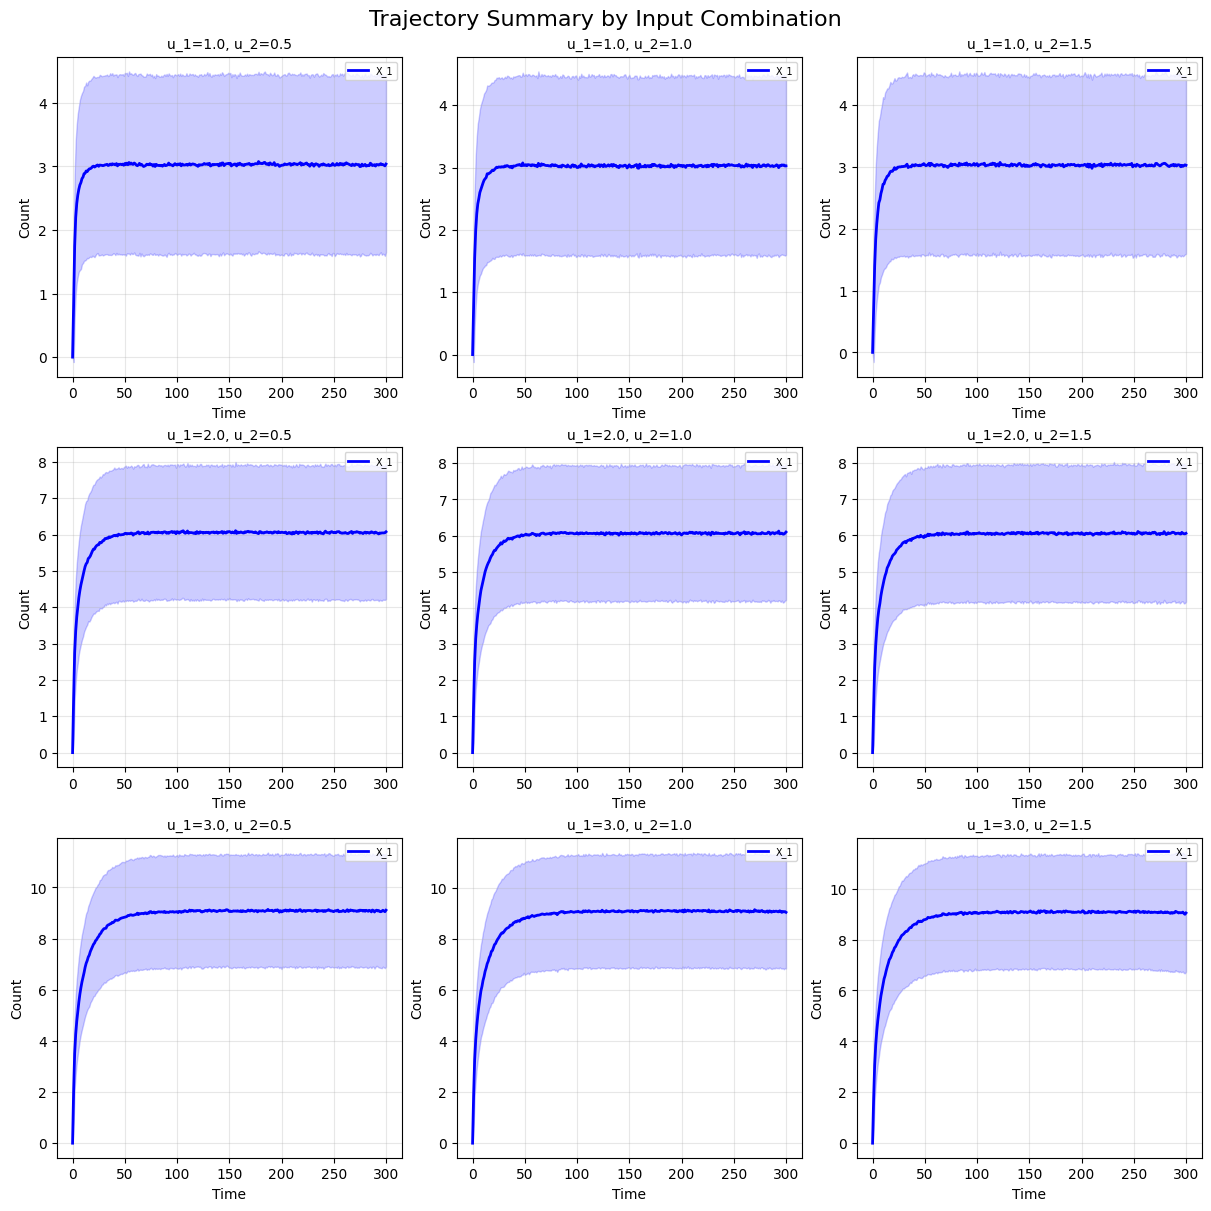

In [26]:
import itertools 
import numpy as np
# Assuming specific library imports exist in your environment context:
# from your_library import make_parser, spread_parameter_sets_among_gpus, SSA, plot_simulation_summary

crn_text = """
// --- Inputs (External Signals) ---
input u_1;
input u_2;

// --- Species Definition ---
species X_1, Z_1, Z_2, Z_3 = 0;

// --- Reactions ---
// 1. Creation of Z_1 driven by u_1
emptyset -- mak(3.0 * u_1) -> Z_1;

// 2. Degradation of X_1 driven by u_2
X_1 -- mak(u_2) -> emptyset;

// 3. X_1 converts to Z_3
X_1 -- mak(0.9901369214057922) -> Z_3;

// 4. Catalytic creation of X_1 by Z_1 (Z_1 is preserved)
Z_1 -- mak(0.9587675929069519) -> X_1, Z_1;

// 5. Interaction of two X_1 molecules resulting in loss of one
X_1, X_1 -- mak(1.1058326959609985) -> X_1;

// 6. Interaction of two X_1 molecules producing Z_2
X_1, X_1 -- mak(1.7381806373596191) -> X_1, Z_2;

// 7. Z_1 and Z_3 combine to form X_1
Z_1, Z_3 -- mak(1.173643946647644) -> X_1;

// 8. Interaction of two Z_2 molecules to form Z_1 and Z_3
Z_2, Z_2 -- mak(1.564497947692871) -> Z_1, Z_3;
"""

# Parse the new CRN
parser, lexer = make_parser()
crn_forthis = parser.parse(crn_text)

# Create combinations of input levels
# Adjusting base range to test different signal intensities
base = [1, 2, 3]
# We have 2 inputs: u_1, u_2
parameters = list(itertools.product(base, [0.5, 1, 1.5]))

# Distribute to GPU
parameter_sets = spread_parameter_sets_among_gpus(parameters)

# Run Simulation
parameter_names = ["u_1", "u_2"]
o = SSA(
    crn_forthis, 
    parameter_sets, 
    parameter_names,
    t_fin=300, 
    n_trajectories=10000, 
    t_step=1., 
    t_control_step=-1, 
    max_value=100000
)

# Visualize Results for all active species
# Included all species defined in your list to ensure complete visibility
plot_simulation_summary(o, species_cols=["X_1"])

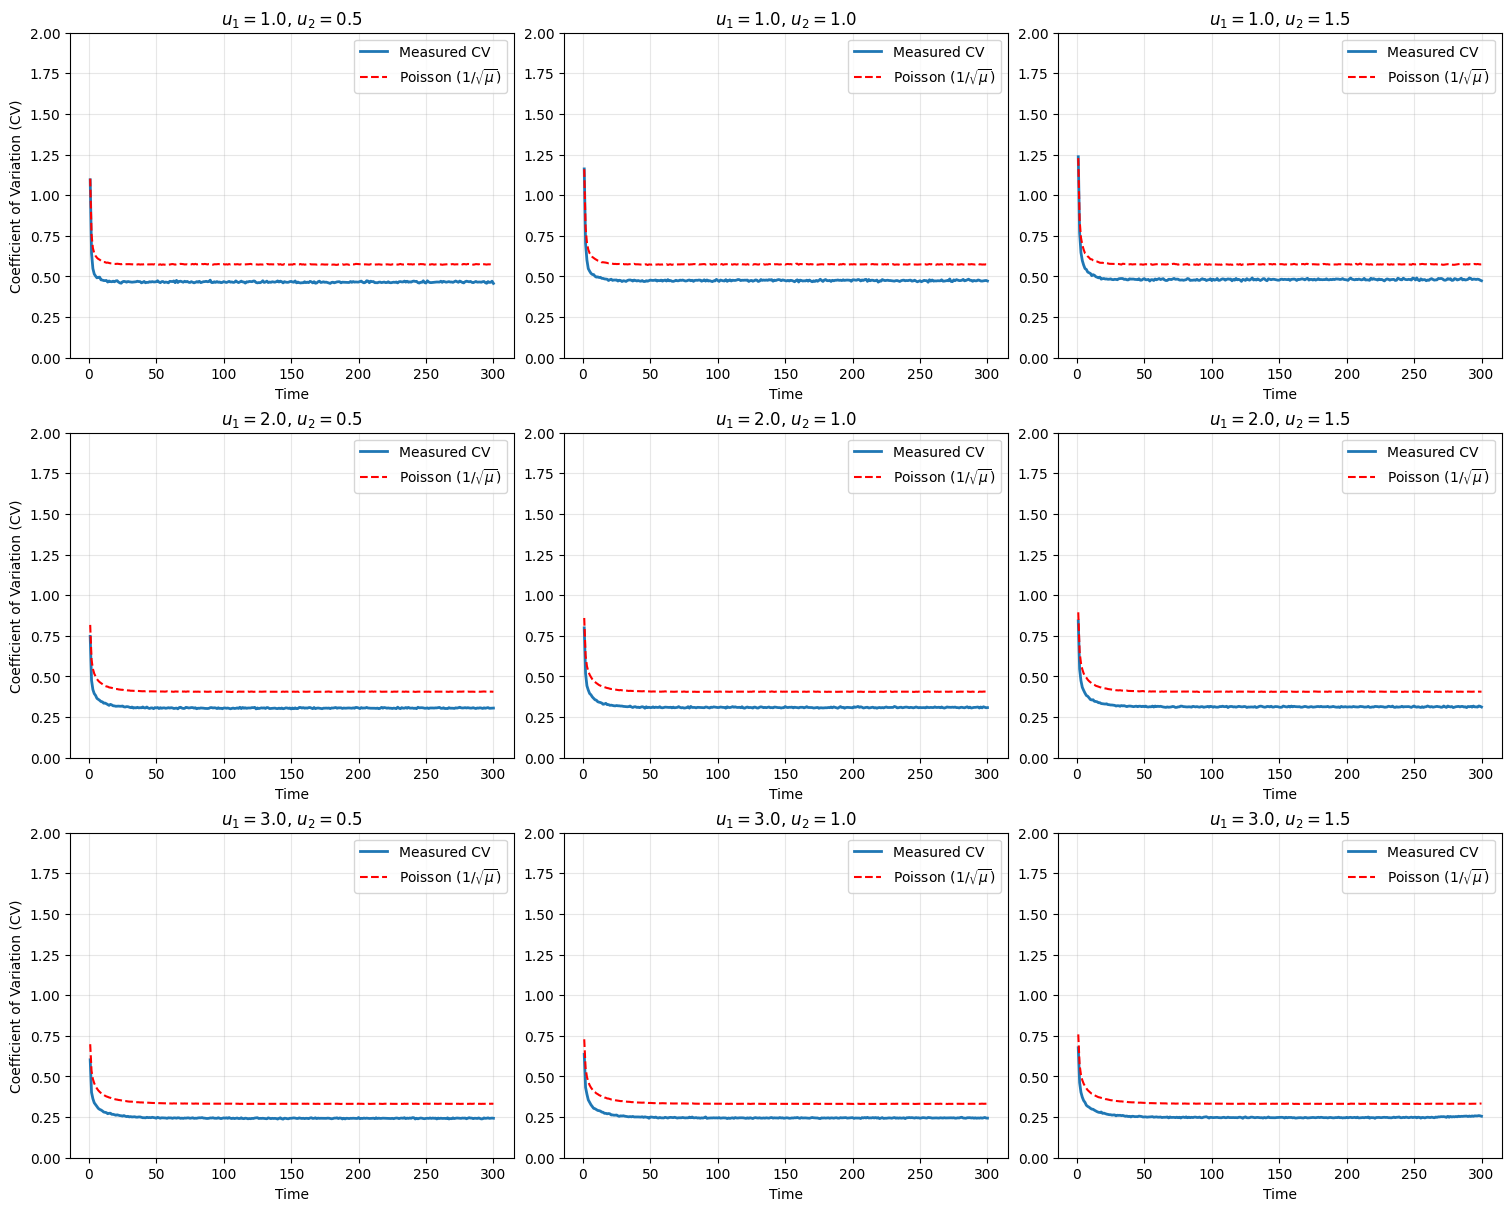

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import math

def plot_cv_comparison(df, species='X_1', params=['u_1', 'u_2']):
    """
    Computes and plots the Coefficient of Variation (CV) over time for different 
    parameter configurations, comparing it with the theoretical Poisson CV.
    
    Parameters:
    -----------
    df : pd.DataFrame
        The simulation results containing time, species counts, and input parameters.
    species : str, optional
        The name of the species column to analyze (default: 'X_1').
    params : list, optional
        List of parameter column names to group by (default: ['u_1', 'u_2']).
    """
    
    # 1. Group and Aggregate
    # We group by time and the parameter columns to get statistics across all trajectories
    # for each specific time point and configuration.
    group_cols = ['time'] + params
    stats = df.groupby(group_cols)[species].agg(['mean', 'std']).reset_index()
    
    # 2. Compute Metrics
    # Filter out very small means to avoid DivisionByZero or exploding CVs at t=0
    stats = stats[stats['mean'] > 1e-6].copy()
    
    # Measured CV = Standard Deviation / Mean
    stats['CV_measured'] = stats['std'] / stats['mean']
    
    # Theoretical Poisson CV = 1 / sqrt(Mean)
    stats['CV_poisson'] = 1 / np.sqrt(stats['mean'])
    
    # 3. Plotting Setup
    # Identify all unique combinations of parameters found in the data
    unique_configs = stats[params].drop_duplicates().values
    n_configs = len(unique_configs)
    
    # Determine dynamic grid size (e.g., fixed 3 columns)
    n_cols = 3
    n_rows = math.ceil(n_configs / n_cols)
    
    # Create figure
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), constrained_layout=True)
    
    # Handle the case of a single plot (axes is not an array)
    if n_configs == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
        
    # Hide any empty subplots at the end of the grid
    for i in range(n_configs, len(axes)):
        axes[i].axis('off')
        
    # 4. Plot Each Configuration
    for i, config_vals in enumerate(unique_configs):
        ax = axes[i]
        
        # Build a filter mask to select rows for this specific configuration
        mask = np.ones(len(stats), dtype=bool)
        title_parts = []
        for col_idx, col_name in enumerate(params):
            val = config_vals[col_idx]
            mask = mask & (stats[col_name] == val)
            title_parts.append(f"${col_name}={val}$")
            
        subset = stats[mask]
        
        # Plotting
        ax.plot(subset['time'], subset['CV_measured'], label='Measured CV', linewidth=2)
        ax.plot(subset['time'], subset['CV_poisson'], label=r'Poisson ($1/\sqrt{\mu}$)', linestyle='--', color='red')
        
        ax.set_title(", ".join(title_parts))
        ax.set_xlabel('Time')
        if i % n_cols == 0:
            ax.set_ylabel('Coefficient of Variation (CV)')
            
        ax.legend()
        ax.grid(True, alpha=0.3)
        
    return fig

fig = plot_cv_comparison(o, species='X_1', params=['u_1', 'u_2'])
# set limits for y-axis if needed
for ax in fig.axes:
    ax.set_ylim(0, 2)
plt.show()

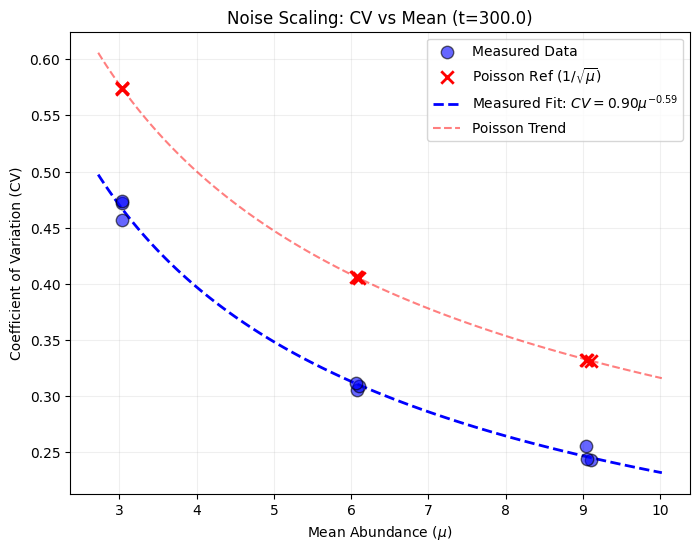

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def power_law(x, a, b):
    return a * np.power(x, b)

def plot_cv_mean_scatter_with_fit(df, species='X_1', params=['u_1', 'u_2']):
    """
    Plots a scatter plot of CV vs Mean for the last time point of the simulation.
    Includes a power-law fit (CV = a * mean^b) for the measured data 
    and compares it with the theoretical Poisson CV (CV = mean^-0.5).
    """
    # 1. Select the last time point
    last_time = df['time'].max()
    df_last = df[df['time'] >= last_time - 1e-9].copy()
    
    # 2. Group by parameters to get statistics
    stats = df_last.groupby(params)[species].agg(['mean', 'std']).reset_index()
    stats = stats[stats['mean'] > 1e-6].copy() # Filter near-zero means
    
    # 3. Compute Metrics
    stats['CV_measured'] = stats['std'] / stats['mean']
    stats['CV_poisson'] = 1 / np.sqrt(stats['mean'])
    
    # 4. Plotting
    plt.figure(figsize=(8, 6))
    
    # Scatter: Measured Data
    plt.scatter(stats['mean'], stats['CV_measured'], 
                color='blue', label='Measured Data', s=80, alpha=0.6, edgecolors='k', zorder=3)
    
    # Scatter: Poisson Reference
    plt.scatter(stats['mean'], stats['CV_poisson'], 
                color='red', label=r'Poisson Ref ($1/\sqrt{\mu}$)', 
                marker='x', s=80, linewidth=2, zorder=3)
    
    # 5. Fitting & Trend Lines
    if not stats.empty:
        min_mean, max_mean = stats['mean'].min(), stats['mean'].max()
        x_line = np.geomspace(min_mean * 0.9, max_mean * 1.1, 100)
        
        # --- Fit for Measured Data ---
        try:
            # Initial guess: a=1, b=-0.5 (close to Poisson)
            popt, _ = curve_fit(power_law, stats['mean'], stats['CV_measured'], p0=[1, -0.5], maxfev=5000)
            y_fit = power_law(x_line, *popt)
            
            # Label with the fitted equation
            fit_label = f'Measured Fit: $CV = {popt[0]:.2f} \mu^{{{popt[1]:.2f}}}$'
            plt.plot(x_line, y_fit, color='blue', linestyle='--', linewidth=2, label=fit_label, zorder=2)
        except Exception as e:
            print(f"Could not fit curve: {e}")

        # --- Theoretical Line ---
        y_theo = 1 / np.sqrt(x_line)
        plt.plot(x_line, y_theo, color='red', linestyle='--', alpha=0.5, label='Poisson Trend', zorder=2)
    
    plt.title(f'Noise Scaling: CV vs Mean (t={last_time:.1f})')
    plt.xlabel('Mean Abundance ($\mu$)')
    plt.ylabel('Coefficient of Variation (CV)')
    
    # Log-Log scale makes it easier to compare the "slope" (scaling exponent)
    # plt.xscale('log')
    # plt.yscale('log')
    
    plt.legend()
    plt.grid(True, which="both", ls="-", alpha=0.2)
    
    return plt.gcf()

# Usage:
# plot_cv_mean_scatter_with_fit(df)
# plt.show()

# Usage with your dataframe 'df':
fig = plot_cv_mean_scatter_with_fit(o, species='X_1', params=['u_1', 'u_2'])
plt.show()

In [17]:
print(o)

         X_1  Z_1  Z_2  Z_3   time  parameter_index  gpu  has_diverged  u_1  \
0          0    0    0    0    0.0                0    0         False    5   
1          3   17    7    2    1.0                0    0         False    5   
2          2   27    3    1    2.0                0    0         False    5   
3          6   28    2    0    3.0                0    0         False    5   
4          3   36    5    0    4.0                0    0         False    5   
...      ...  ...  ...  ...    ...              ...  ...           ...  ...   
9089995   16  370   12    0   96.0                8    0         False    7   
9089996   19  344   11    0   97.0                8    0         False    7   
9089997   15  330    7    1   98.0                8    0         False    7   
9089998   16  311   20    0   99.0                8    0         False    7   
9089999   16  288   10    1  100.0                8    0         False    7   

         u_2  
0        0.5  
1        0.5  
2     

[<LanguageBlocks.Reaction object at 0x7fea5b250f40>, <LanguageBlocks.Reaction object at 0x7fea5b2535b0>, <LanguageBlocks.Reaction object at 0x7fea5b16e1d0>, <LanguageBlocks.Reaction object at 0x7fea5b219d50>]


INFO:root:GPU 0 finished in 0.09627819061279297 seconds


Plotting mode: Raw (Aggregating now)


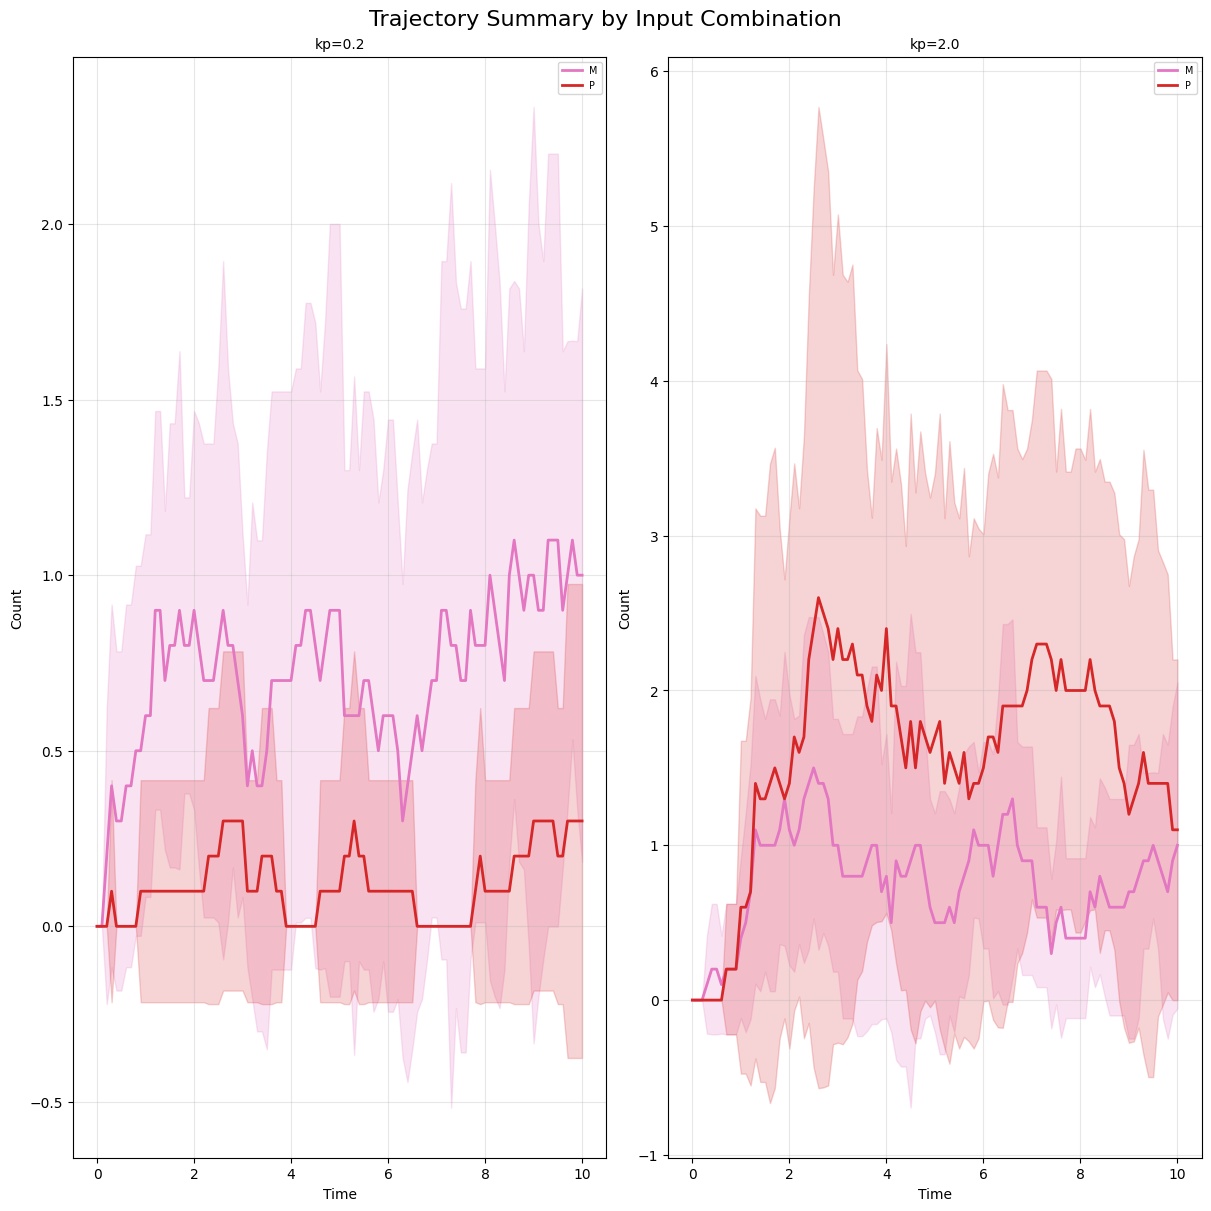

In [18]:
crn_text = """ 
//input kr;
input kp;
gr = 1;
gp = 1;
//kp = 1;
kr = 1;
species M, P = 0;

emptyset -- kr -> M:1;
M:1 -- mak(kp) -> M:1, P:1;
//M:1 -- mak(kp) -> P:1; // if we want the MRNA to be consumed
M:1 -- mak(gr) -> emptyset;
P:1 -- mak(gp) -> emptyset;
"""

# Parse the new CRN
parser, lexer = make_parser()
crn_forthis = parser.parse(crn_text)

# Create combinations of input levels
# Adjusting base range to test different signal intensities
parameters = [[0.2], [2]]

# Distribute to GPU
parameter_sets = spread_parameter_sets_among_gpus(parameters)

# Run Simulation

print(crn_forthis.reactions)

# Using the optimized settings you requested
parameter_names = ["kp"]
o = SSA(
    crn_forthis, 
    parameter_sets, 
    parameter_names,
    t_fin=10, 
    n_trajectories=10, 
    t_step=0.1, 
    t_control_step=-1, 
    max_value=100000
)

# Visualize Results for all active species
plot_simulation_summary(o, species_cols=["M", "P"], input_cols=["kp"])


Warinig: multiple uses of species X_1 in same reaction. The number of involved molecules is summed by default
Warinig: multiple uses of species X_1 in same reaction. The number of involved molecules is summed by default


INFO:root:GPU 0 finished in 0.34937405586242676 seconds


Plotting mode: Raw (Aggregating now)


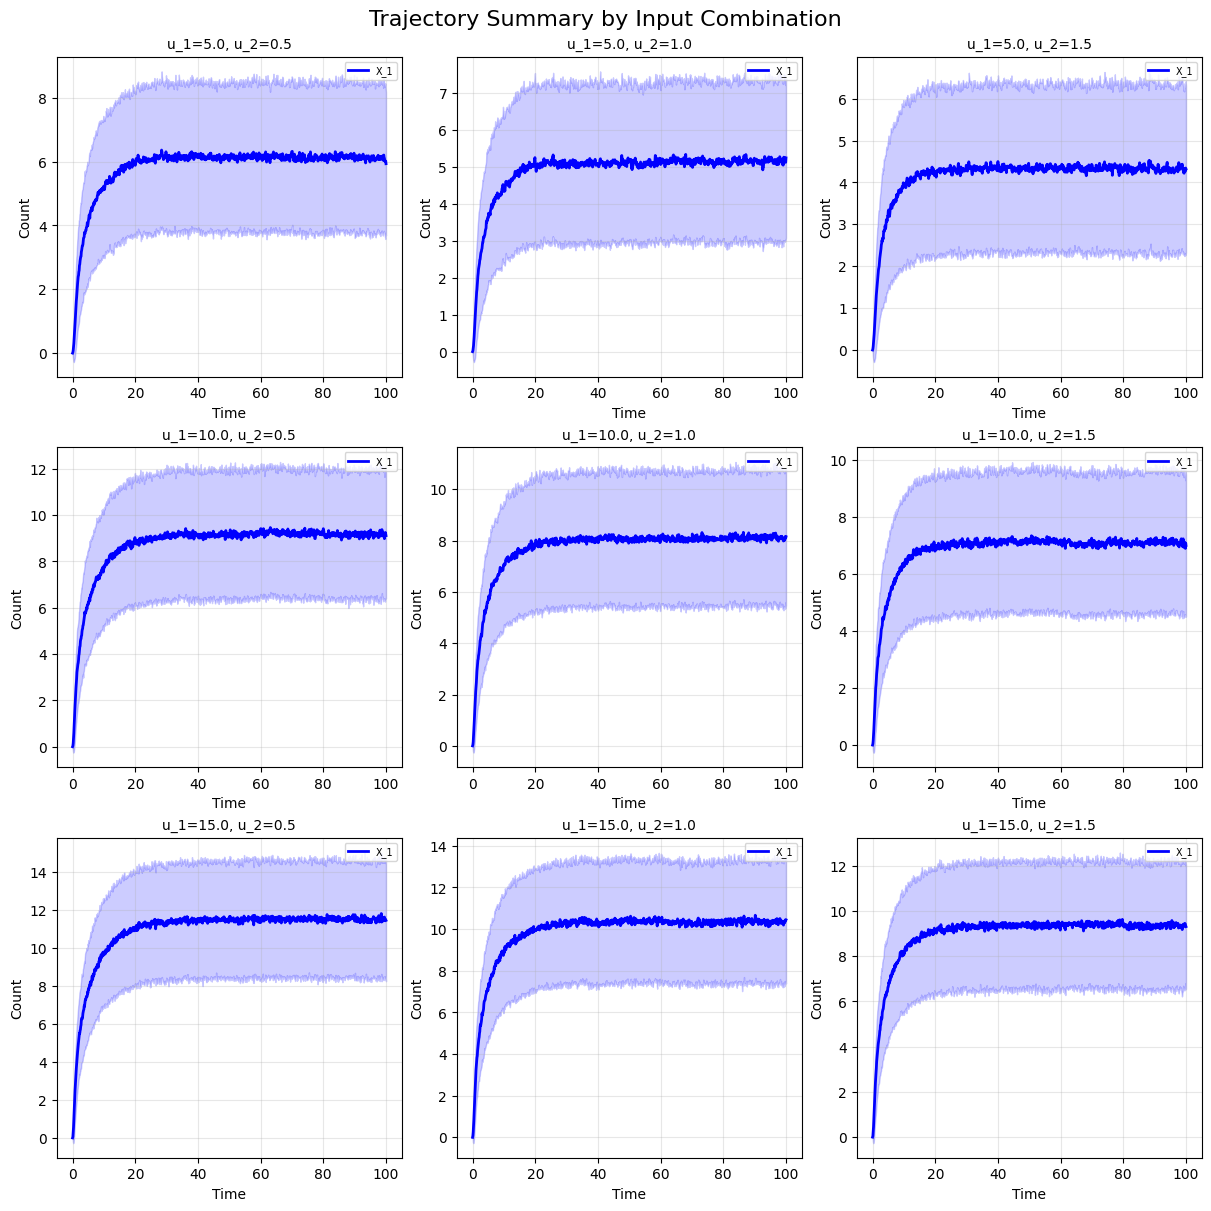

In [19]:
import itertools 
import numpy as np
# Assuming specific library imports exist in your environment context:
# from your_library import make_parser, spread_parameter_sets_among_gpus, SSA, plot_simulation_summary

crn_text = """
// --- Inputs (External Signals) ---
input u_1;
input u_2;

// --- Species Definition ---
species X_1, Z_1, Z_2 = 0;

// --- Reactions ---
// 1. Creation of Z_1 driven by u_1 (No reactants, so no mak() wrapper)
emptyset -- 1.0 * u_1 -> Z_1;

// 2. Degradation of X_1 driven by u_2
X_1 -- mak(1.0 * u_2) -> emptyset;

// 3. Degradation of Z_1
Z_1 -- mak(0.45389291644096375) -> emptyset;

// 4. Catalytic replication of X_1 via Z_1
Z_1 -- mak(0.9004634022712708) -> X_1, Z_1;

// 5. Conversion of Z_2 to X_1
Z_2 -- mak(2.174746513366699) -> X_1;

// 6. Annihilation of X_1 pairs
X_1, X_1 -- mak(0.1794494241476059) -> emptyset;

// 7. Fusion of X_1 pairs to form Z_1
X_1, X_1 -- mak(0.511475682258606) -> Z_1;
"""

# Parse the new CRN
parser, lexer = make_parser()
crn_forthis = parser.parse(crn_text)

# Create combinations of input levels
base = [5, 10, 15]
# We have 2 inputs: u_1, u_2
parameters = list(itertools.product(base, [0.5, 1, 1.5]))
parameter_names = ["u_1", "u_2"]

# Distribute to GPU
parameter_sets = spread_parameter_sets_among_gpus(parameters)

# Run Simulation
o = SSA(
    crn_forthis, 
    parameter_sets, 
    parameter_names,
    t_fin=100, 
    n_trajectories=1000, 
    t_step=0.1, 
    t_control_step=-1, 
    max_value=100000
)

# Visualize Results for all active species
plot_simulation_summary(o, species_cols=["X_1"])

Warinig: multiple uses of species Z_1 in same reaction. The number of involved molecules is summed by default
Warinig: multiple uses of species X_1 in same reaction. The number of involved molecules is summed by default
Warinig: multiple uses of species Z_1 in same reaction. The number of involved molecules is summed by default
Warinig: multiple uses of species X_1 in same reaction. The number of involved molecules is summed by default
Warinig: multiple uses of species Z_2 in same reaction. The number of involved molecules is summed by default


INFO:root:GPU 0 finished in 0.3940093517303467 seconds


Plotting mode: Raw (Aggregating now)


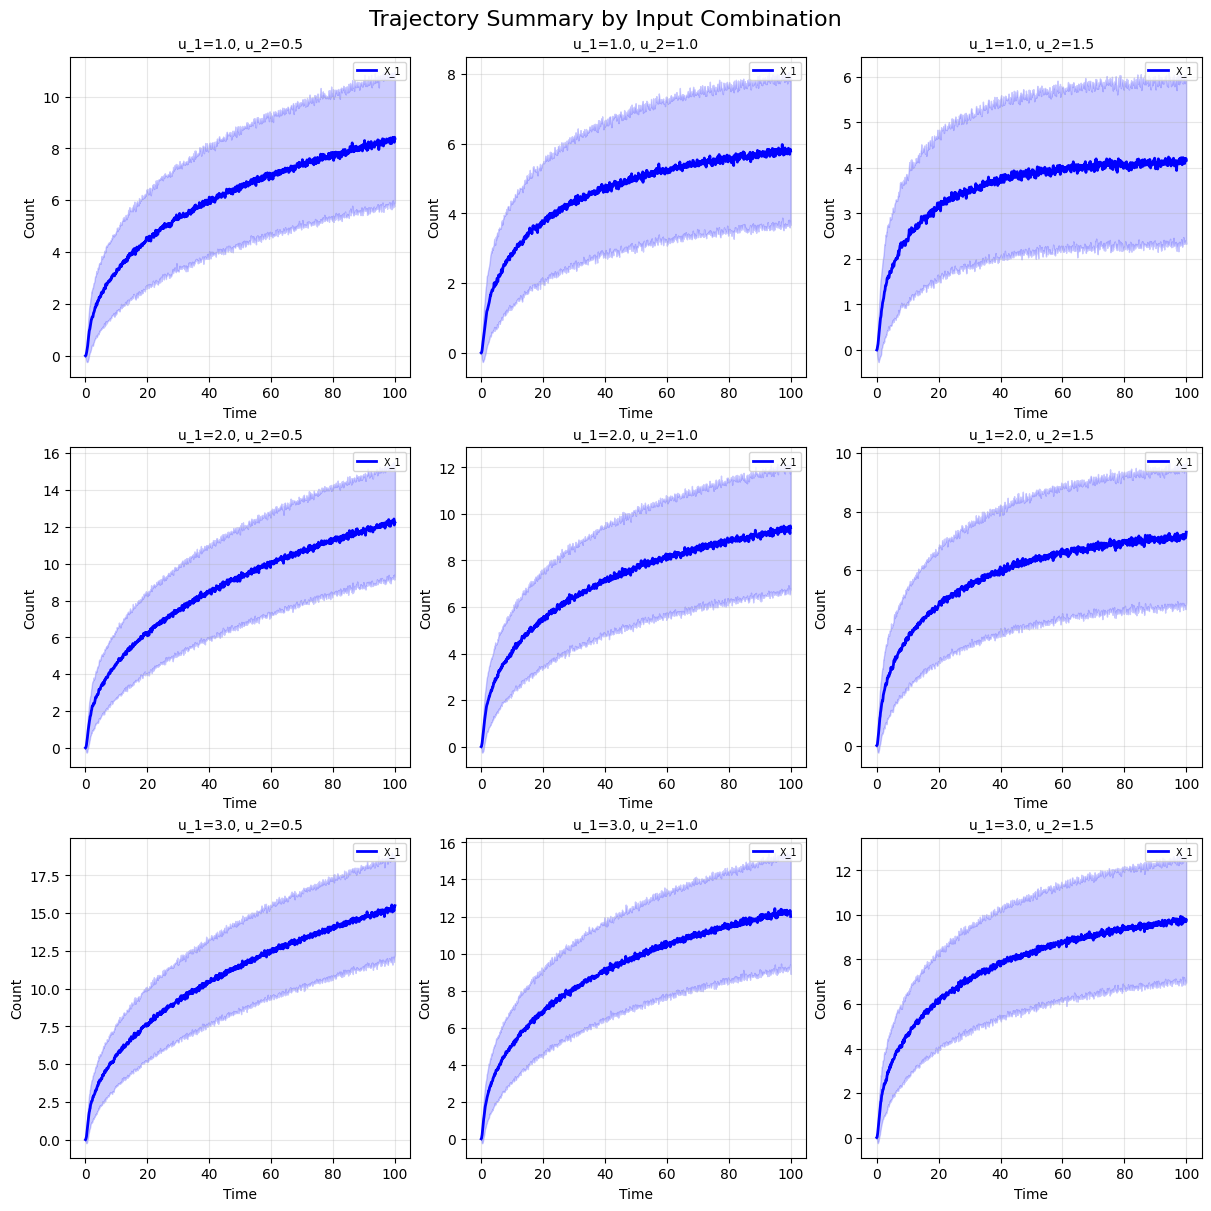

In [20]:
import itertools 
import numpy as np
# Assuming specific library imports exist in your environment context:
# from your_library import make_parser, spread_parameter_sets_among_gpus, SSA, plot_simulation_summary

crn_text = """
// --- Inputs (External Signals) ---
input u_1;
input u_2;

// --- Species Definition ---
species X_1, Z_1, Z_2 = 0;

// --- Reactions ---
// 1. Creation of Z_1 driven by u_1 (Source: no reactants -> no mak wrapper)
emptyset -- 5.0 * u_1 -> Z_1;

// 2. Creation of Z_1 pair (Source: no reactants -> no mak wrapper)
emptyset -- 0.6528577208518982 -> Z_1, Z_1;

// 3. Degradation of X_1 driven by u_2
X_1 -- mak(1.0 * u_2) -> emptyset;

// 4. Conversion of Z_1 to X_1
Z_1 -- mak(0.3421388566493988) -> X_1;

// 5. Conversion of Z_2 to Z_1
Z_2 -- mak(0.5117623209953308) -> Z_1;

// 6. Interaction of X_1 pairs to form Z_1 pairs
X_1, X_1 -- mak(0.8288071751594543) -> Z_1, Z_1;

// 7. Interaction of X_1 pairs to form Z_2 pairs
X_1, X_1 -- mak(0.43717673420906067) -> Z_2, Z_2;
"""

# Parse the new CRN
parser, lexer = make_parser()
crn_forthis = parser.parse(crn_text)

# Create combinations of input levels
base = [1, 2, 3]
# We have 2 inputs: u_1, u_2
parameters = list(itertools.product(base, [0.5, 1., 1.5]))
parameter_names = ["u_1", "u_2"]

# Distribute to GPU
parameter_sets = spread_parameter_sets_among_gpus(parameters)

# Run Simulation
o = SSA(
    crn_forthis, 
    parameter_sets, 
    parameter_names,
    t_fin=100, 
    n_trajectories=1000, 
    t_step=0.1, 
    t_control_step=-1, 
    max_value=100000
)

# Visualize Results for all active species
plot_simulation_summary(o, species_cols=["X_1"])

In [21]:
parameter_sets

[[(1, 0.5),
  (1, 1.0),
  (1, 1.5),
  (2, 0.5),
  (2, 1.0),
  (2, 1.5),
  (3, 0.5),
  (3, 1.0),
  (3, 1.5)]]

In [22]:
o

,X_1,Z_1,Z_2,time,parameter_index,gpu,has_diverged,u_1,u_2
0,0,0,0,0.0,0,0,False,1,0.5
1,0,1,0,0.1,0,0,False,1,0.5
2,0,1,0,0.2,0,0,False,1,0.5
3,0,2,0,0.3,0,0,False,1,0.5
4,0,4,0,0.4,0,0,False,1,0.5
...,...,...,...,...,...,...,...,...,...
9008995,5,400,87,99.6,8,0,False,3,1.5
9008996,10,396,88,99.7,8,0,False,3,1.5
9008997,11,397,85,99.8,8,0,False,3,1.5
9008998,12,402,85,99.9,8,0,False,3,1.5
